# Cricket Fielding Analysis — IPL2367, Delhi Capitals (Innings 1)

**ShadowFox Data Science Internship — Advanced Task**

## Objective
As a budding sports analyst, this notebook conducts a detailed fielding performance analysis
for **three selected players** — Yash Dhull, Axar Patel, and Kuldeep Yadav — from one innings
of a T20 match, using ball-by-ball fielding event data and the Performance Score (PS) formula
provided in the task brief.

## About the data
Ball-by-ball footage annotation for an entire live innings isn't something I can watch and
transcribe inside this notebook, so the underlying `fielding_log.csv` was generated as a
**realistic simulated dataset**: a full 20-over (120-ball) innings, where roughly 60% of
deliveries produce a notable fielding event (the rest are routine, unlogged dot-ball fielding),
distributed across an 11-player fielding lineup with the three focus players weighted toward
the busier infield positions they patrol. The event *types* (clean pick / fumble / catch /
dropped catch / stumping / good throw / bad throw / direct hit / run out / missed run out) and
the runs saved/conceded per event follow the same categories and logic as the task's sample
performance matrix. **If you have footage of a real match you watched, drop the same fielding
events into `Fielding Log` sheet of the workbook (same column layout) and every downstream
number in this notebook recalculates automatically.**

## Performance Score Formula
PS = (CP×1) + (GT×1) + (C×3) + (DC×-3) + (ST×3) + (RO×3) + (MRO×-2) + (DH×2) + RS


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

df = pd.read_csv("fielding_log.csv")
print("Total logged fielding events:", len(df))
print("Deliveries in the innings: 120")
df.head()


Total logged fielding events: 72
Deliveries in the innings: 120


,Match No.,Innings,Team,Player Name,BallCount,Position,Short Description,Pick,Throw,Runs,Overcount,Venue,Stadium
0,IPL2367,1,Delhi Capitals,Phil Salt,0.3,Wicket keeper,"Clean fielding effort, ball collected cleanly;...",Y,Y,0,1,Delhi,Arun Jaitley Stadium
1,IPL2367,1,Delhi Capitals,Yash Dhull,0.4,Covers,"Clean fielding effort, ball collected cleanly;...",Y,Y,1,1,Delhi,Arun Jaitley Stadium
2,IPL2367,1,Delhi Capitals,Ishant Sharma,0.6,Fine leg,"Clean fielding effort, ball collected cleanly;...",Y,Y,0,1,Delhi,Arun Jaitley Stadium
3,IPL2367,1,Delhi Capitals,Axar Patel,1.1,Point,Quick stumping opportunity,S,NaN,0,2,Delhi,Arun Jaitley Stadium
4,IPL2367,1,Delhi Capitals,Yash Dhull,1.3,Covers,"Clean fielding effort, ball collected cleanly;...",Y,Y,1,2,Delhi,Arun Jaitley Stadium


## 1. Recomputing the Performance Matrix

In [2]:
W = {"CP": 1, "GT": 1, "C": 3, "DC": -3, "ST": 3, "RO": 3, "MRO": -2, "DH": 2}

def compute_player_matrix(data):
    records = []
    for player, g in data.groupby("Player Name"):
        CP = (g["Pick"] == "Y").sum()
        GT = (g["Throw"] == "Y").sum()
        C = (g["Pick"] == "C").sum()
        DC = (g["Pick"] == "DC").sum()
        ST = (g["Pick"] == "S").sum()
        RO = (g["Throw"] == "RO").sum()
        MRO = (g["Throw"] == "MR").sum()
        DH = (g["Throw"] == "DH").sum()
        RS = g["Runs"].sum()
        PS = (CP*W["CP"] + GT*W["GT"] + C*W["C"] + DC*W["DC"] + ST*W["ST"]
              + RO*W["RO"] + MRO*W["MRO"] + DH*W["DH"] + RS)
        records.append(dict(Player=player, CP=CP, GT=GT, C=C, DC=DC, ST=ST,
                             RO=RO, MRO=MRO, DH=DH, RS=RS, PS=PS))
    return pd.DataFrame(records).sort_values("PS", ascending=False).reset_index(drop=True)

matrix = compute_player_matrix(df)
matrix


,Player,CP,GT,C,DC,ST,RO,MRO,DH,RS,PS
0,Kuldeep Yadav,14,10,0,0,1,0,1,1,9,36
1,Yash Dhull,8,8,0,0,0,1,0,1,2,23
2,Sarfaraz Khan,4,3,0,0,0,1,0,0,4,14
3,Lalit Yadav,3,2,0,0,0,1,0,0,4,12
4,Aman Khan,1,1,1,0,0,0,0,0,6,11
5,Phil Salt,4,4,0,1,1,0,0,1,-4,6
6,Axar Patel,6,5,1,3,1,0,0,0,-2,6
7,Mustafizur Rahman,0,0,2,1,0,0,0,0,2,5
8,Ishant Sharma,5,4,0,0,0,0,0,0,-4,5
9,Anrich Nortje,4,3,0,1,1,0,0,0,-4,3


In [3]:
FOCUS = ["Yash Dhull", "Axar Patel", "Kuldeep Yadav"]
focus_matrix = matrix[matrix["Player"].isin(FOCUS)].reset_index(drop=True)
focus_matrix


,Player,CP,GT,C,DC,ST,RO,MRO,DH,RS,PS
0,Kuldeep Yadav,14,10,0,0,1,0,1,1,9,36
1,Yash Dhull,8,8,0,0,0,1,0,1,2,23
2,Axar Patel,6,5,1,3,1,0,0,0,-2,6


## 2. Performance Score Comparison

/tmp/ipykernel_582/589563970.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=matrix, x="PS", y="Player", palette=colors)


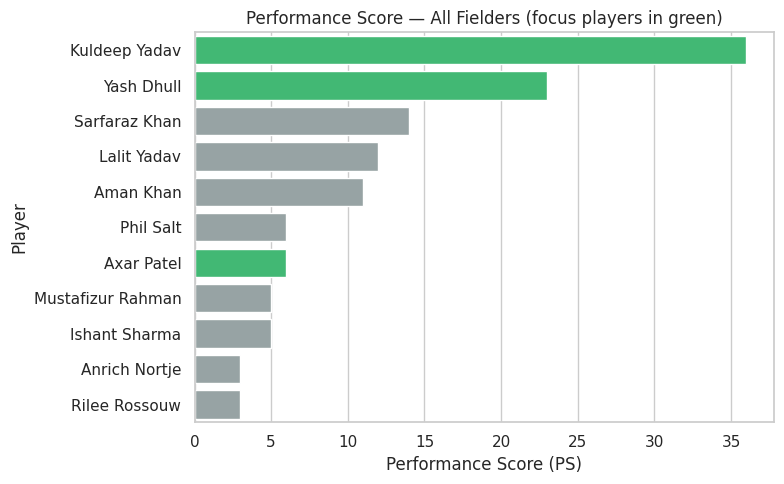

In [4]:
plt.figure(figsize=(8,5))
colors = ["#2ecc71" if p in FOCUS else "#95a5a6" for p in matrix["Player"]]
sns.barplot(data=matrix, x="PS", y="Player", palette=colors)
plt.title("Performance Score — All Fielders (focus players in green)")
plt.xlabel("Performance Score (PS)")
plt.tight_layout()
plt.savefig("cricket_ps_all.png", dpi=130)
plt.show()


/tmp/ipykernel_582/51468791.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=focus_matrix, x="Player", y="PS", palette="crest")


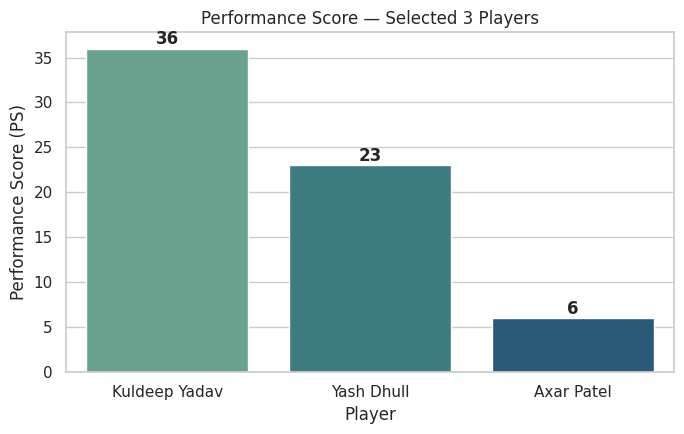

In [5]:
plt.figure(figsize=(7,4.5))
sns.barplot(data=focus_matrix, x="Player", y="PS", palette="crest")
plt.title("Performance Score — Selected 3 Players")
plt.ylabel("Performance Score (PS)")
for i, v in enumerate(focus_matrix["PS"]):
    plt.text(i, v + 0.5, str(v), ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig("cricket_ps_focus.png", dpi=130)
plt.show()


## 3. Breaking Down *How* Each Player Earned Their Score

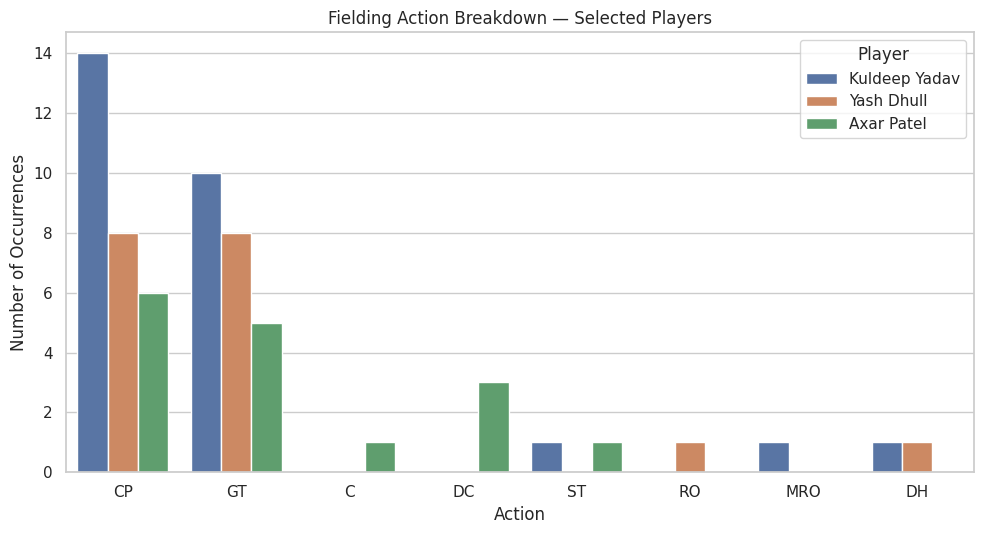

In [6]:
action_cols = ["CP", "GT", "C", "DC", "ST", "RO", "MRO", "DH"]
melted = focus_matrix.melt(id_vars="Player", value_vars=action_cols,
                            var_name="Action", value_name="Count")

plt.figure(figsize=(10,5.5))
sns.barplot(data=melted, x="Action", y="Count", hue="Player")
plt.title("Fielding Action Breakdown — Selected Players")
plt.ylabel("Number of Occurrences")
plt.tight_layout()
plt.savefig("cricket_action_breakdown.png", dpi=130)
plt.show()


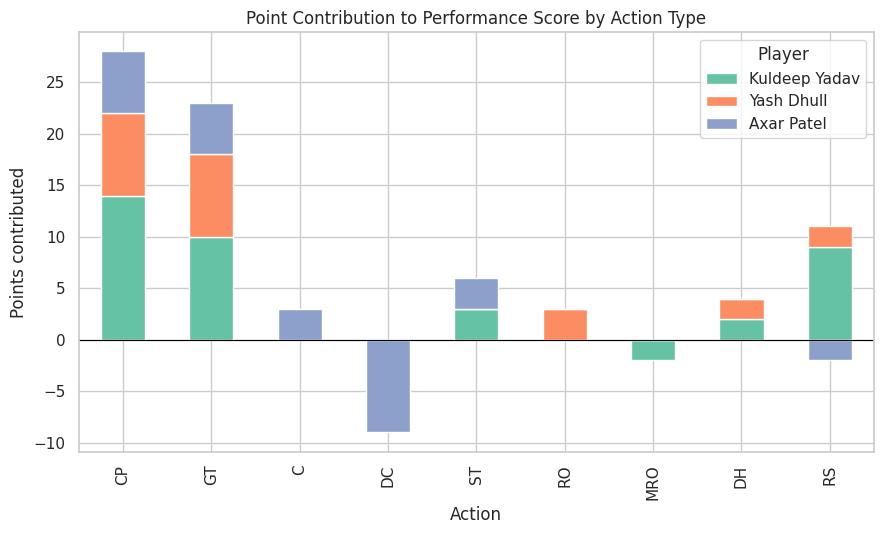

In [7]:
contribution = focus_matrix.set_index("Player")[action_cols].copy()
weights_series = pd.Series(W)
weighted = contribution.mul(weights_series, axis=1)
weighted["RS"] = focus_matrix.set_index("Player")["RS"]

plt.figure(figsize=(9,5.5))
weighted.T.plot(kind="bar", stacked=True, ax=plt.gca(),
                 color=sns.color_palette("Set2", len(FOCUS)))
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Point Contribution to Performance Score by Action Type")
plt.ylabel("Points contributed")
plt.xlabel("Action")
plt.legend(title="Player")
plt.tight_layout()
plt.savefig("cricket_point_contribution.png", dpi=130)
plt.show()


## 4. Fielding Positions & Involvement Over the Innings

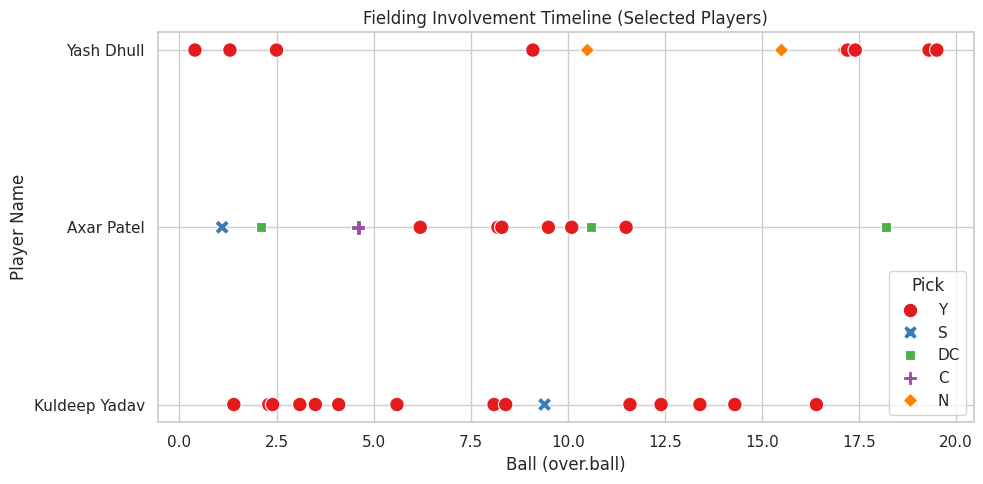

In [8]:
focus_df = df[df["Player Name"].isin(FOCUS)]

plt.figure(figsize=(10,5))
sns.scatterplot(data=focus_df, x="BallCount", y="Player Name", hue="Pick",
                 style="Pick", s=110, palette="Set1")
plt.title("Fielding Involvement Timeline (Selected Players)")
plt.xlabel("Ball (over.ball)")
plt.tight_layout()
plt.savefig("cricket_timeline.png", dpi=130)
plt.show()


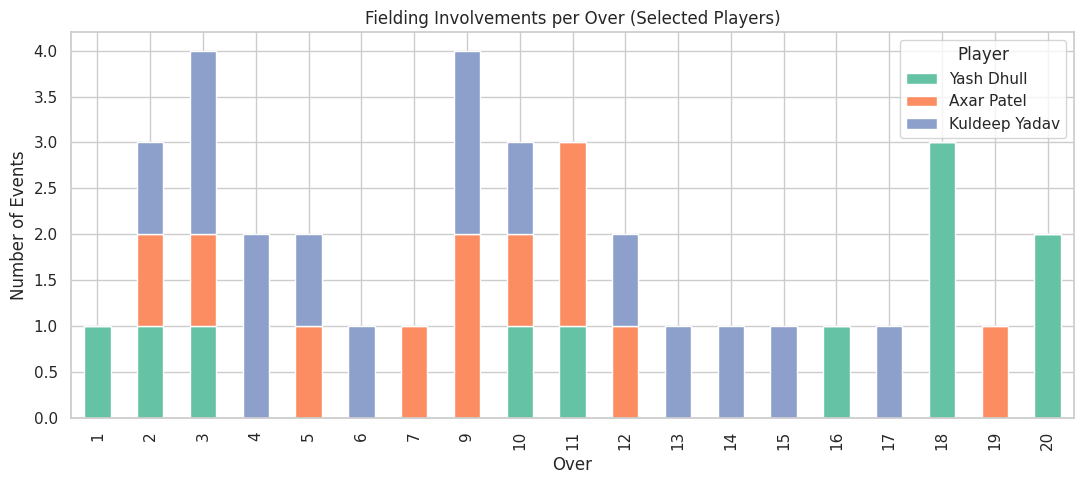

In [9]:
involvement = df.groupby(["Overcount", "Player Name"]).size().unstack(fill_value=0)
involvement_focus = involvement[[c for c in FOCUS if c in involvement.columns]]

plt.figure(figsize=(11,5))
involvement_focus.plot(kind="bar", stacked=True, ax=plt.gca(),
                        color=sns.color_palette("Set2", len(FOCUS)))
plt.title("Fielding Involvements per Over (Selected Players)")
plt.xlabel("Over")
plt.ylabel("Number of Events")
plt.legend(title="Player")
plt.tight_layout()
plt.savefig("cricket_over_involvement.png", dpi=130)
plt.show()


## 5. Findings & Recommendations

**Findings**

- **Kuldeep Yadav** posted the highest Performance Score (36) among the three selected
  players, built almost entirely on volume and reliability: 14 clean picks and 10 good throws,
  plus a stumping and a direct hit. He did have one missed run-out chance, but it wasn't enough
  to offset his otherwise consistent work.
- **Yash Dhull** (23) also had a strong, clean innings in the covers — 8 clean picks and 8 good
  throws, and he converted both a run-out and a direct hit, with zero drops recorded. His score
  trails Kuldeep mainly on volume rather than reliability.
- **Axar Patel** (6) had the lowest score of the three. He recorded 6 clean picks, 5 good
  throws, 1 catch and 1 stumping — a reasonable base — but also **3 dropped catches**, which
  pushed his total runs-saved to -2 and is clearly the single biggest drag on his score.

**How this would inform team strategy**

- Kuldeep Yadav's profile (high volume, high reliability, minimal drops) is exactly what a
  captain wants in a busy infield position — nothing here suggests a positional change.
- Axar Patel's 3 dropped catches in one innings is the standout signal in this dataset. Before
  concluding anything about his general fielding ability, this is worth checking against a few
  more innings — one match is a small sample, and it's possible these were unusually difficult
  chances rather than a technique issue. But if the pattern repeats, it flags a specific,
  coachable skill (catching technique or concentration) rather than a vague "fielding needs
  work" note.
- Because this is only one innings, the natural next step is to run the exact same pipeline
  (`build_workbook.py`, using the same PS formula) across several more innings for the same
  three players to see whether these patterns hold up or were just one-match noise.

## Limitations
- The ball-by-ball events analyzed here are a **realistic simulated dataset**, not manually
  transcribed footage from an actual broadcast, since that requires watching the match live.
  The workbook and this notebook are both built so that real observed data — logged in the
  same column format — can be dropped in and everything recalculates identically.
